In [1]:
import numpy as np 
import pandas as pd 
import h5py
import re
import uproot
import glob 
import copy, sys, os
import matplotlib.pyplot as plt
from tqdm import tqdm 
# adding path to folder
sys.path.insert(0, '../tools/')
#from utils import ParticleCode, load_dataset
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match
# Load your custom style 
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True

In [2]:
def load_keys(keys_set):
    if(keys_set=="n-Ar"):
        input_keys = "./cfg/caf_keys.txt"
    keys_list = open(input_keys,'r')
    data = []
    for line in keys_list:
        line = line.strip()
        data.append(line)
    return data

def load_dataset(n_files,location):
    print("Openning MiniRun 5 beta 2.a CAFs")
    print("Reading ", n_files, " files")

    if(location=="nersc"):
        input_list = "./cfg/minirun5_noe_fix.txt"
    else:
        input_list = "./cfg/minirun_5_beta2a_fnal.txt"
    file_list = open(input_list, 'r')
    data = []
    df = pd.DataFrame(data)
    counter = 0
    counter_max = n_files 
    for line in tqdm(file_list):
        if(counter > counter_max):
            break
        else:
            line = line.strip()
            #print("Reading", line)
            caf_file = uproot.open(line)
            caf_tree = caf_file['cafTree']
            # Create an empty dictionary to store branch data
            caf_data_dict = {}
            # Import list of keys for n-Ar
            caf_keys = load_keys("n-Ar")
            #Iterate over the branch names in the TTree
            for branch_name in caf_keys:
                # Use branch_name as the key and fetch the data using .array()
                caf_data_dict[branch_name] = caf_tree[branch_name].array(library="np")
            # Create a Pandas DataFrame from the dictionary
            df_temp = pd.DataFrame(caf_data_dict)
            df = pd.concat([df, df_temp])
            counter+=1
    return df 

class ParticleCode():
    # Class containing pdg codes
    def __init__(self):

        # Massess
        self.neutron_mass = 939.5654 # MeV/c2 
        self.proton_mass = 938.2702 # MeV/c2


        # PDG Codes 
        self.argon = 1000180400
        self.chlorine = 1000170360
        self.sulfur = 1000160320 
        self.muon = 13
        self.neutron = 2112
        self.electron = 11 
        self.pi0 = 111
        self.pip = 211
        self.eta = 221
        self.proton = 2212
        self.numu = 14
        self.nue = 12
        self.photon = 22

def Mx2_DS_Match(reco_track, minerva_data):


    # Variables to return 
    ds_dp = 0 
    bm_index = None
    exit_minerva = False
    deltaX = None
    deltaY = None


    tpc_track_s = reco_track[0]
    tpc_track_e = reco_track[1]

    # Data of tpc track 
    tpc_dx = tpc_track_e[0] - tpc_track_s[0]  
    tpc_dy = tpc_track_e[1] - tpc_track_s[1]
    tpc_dz = tpc_track_e[2] - tpc_track_s[2]
    tpc_trk_length = np.sqrt(np.square(tpc_dx) + np.square(tpc_dy) + np.square(tpc_dz))
    tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length
    #print(f"2x2 track length {tpc_trk_length:.2f} cm")

    if(tpc_dir_vec[2]<0):
        # print("Flipping track direction")
        # print(f"Original start {tpc_track_s}")
        # print(f"Original end {tpc_track_e}")
        tpc_dir_vec[2] = -1*tpc_dir_vec[2]
        temp = tpc_track_s
        tpc_track_s = tpc_track_e
        tpc_track_e = temp 
        # print(f"New start {tpc_track_s}")
        # print(f"New end {tpc_track_e}")

    # Hard coded 5 cm (?)
    if(tpc_trk_length>5):
        if(tpc_track_s[2] > 58 or tpc_track_e[2] > 58):
            temp_punchthrough = -1
            nminerva_tracks = np.sum(minerva_data['rec.nd.minerva.ixn.tracks..length'])
            for itrack in range(nminerva_tracks):

                mn_track_sx = minerva_data['rec.nd.minerva.ixn.tracks.start.x'][itrack]
                mn_track_sy = minerva_data['rec.nd.minerva.ixn.tracks.start.y'][itrack]
                mn_track_sz = minerva_data['rec.nd.minerva.ixn.tracks.start.z'][itrack]

                mn_track_ex = minerva_data['rec.nd.minerva.ixn.tracks.end.x'][itrack]
                mn_track_ey = minerva_data['rec.nd.minerva.ixn.tracks.end.y'][itrack]
                mn_track_ez = minerva_data['rec.nd.minerva.ixn.tracks.end.z'][itrack]

                if(mn_track_ez>300):
                    exit_minerva=True


                # Only DS track
                if(mn_track_sz > 0 and mn_track_ez > 0 and
                   ((tpc_track_s[2] > 58) or (tpc_track_e[2] > 58))):
                    mn_dx = mn_track_ex - mn_track_sx
                    mn_dy = mn_track_ey - mn_track_sy
                    mn_dz = mn_track_ez - mn_track_sz
                    mn_length = np.sqrt(np.square(mn_dx) + 
                                        np.square(mn_dy) + 
                                        np.square(mn_dz))    

                    if(mn_length<10):
                        continue 
                    mn_dir = np.array([
                        mn_dx,
                        mn_dy,
                        mn_dz
                    ])/mn_length
                    dot_product = np.dot(tpc_dir_vec,mn_dir)  
                    extrapdz = mn_track_sz - tpc_track_e[2]
                    extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
                    extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
                    diffextrap = np.sqrt(np.square(extrapdy - mn_track_sy))

                    if(ds_dp < dot_product and np.abs(extrapdy)< 10):
                        ds_dp = dot_product
                        bm_index = itrack
                        deltaX = extrapdx 
                        deltaY = extrapdy

    return bm_index,ds_dp,deltaX,deltaY,exit_minerva

In [3]:
# Load datasets 
n_files = 998
location = "nersc"
df = load_dataset(n_files,location)
# Create a caf reader
caf_reader = CafReader(df)
pdg_tab = ParticleCode()

Openning MiniRun 5 beta 2.a CAFs
Reading  998  files


0it [00:00, ?it/s]

877it [18:14,  1.25s/it]


In [4]:
#dimensions of the detector
anode_xs = np.array([-63.931, -3.069, 3.069, 63.931])
anode_ys = np.array([-19.8543, 103.8543]) - 42  # Subtract 42 from all y coordinates
anode_zs = np.array([-64.3163, -2.6837, 2.6837, 64.3163])
#Fiducial Volume
tpc_dist = 8.0
xbound = 63.931
ybound = 62.076
zbound = 64.3163

In [5]:
#find if an interaction is contained in FV
def isContainedFV(vx,vy,vz, tpc_dist=10):
    #tpc_dist = 10.0
    xbound = 63.931
    ybound = 62.076
    zbound = 64.3163

    if(
        abs(vx)<xbound-tpc_dist and
        abs(vx)>tpc_dist and
        abs(vy)<ybound-tpc_dist and
        abs(vz)>tpc_dist and
        abs(vz)<zbound-tpc_dist
    ): 
        return True
    else: return False


#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

#TRUE: filter the true ccmunu fv signal to tracks that exit 2x2 downstream
def find_end_muon(ev_data, mask_signal):
    muon_out = np.zeros_like(mask_signal, dtype=bool)
    for vtx, value in enumerate(mask_signal):
        if value:
            n_tracks = ev_data['rec.mc.nu.prim..length'][vtx]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx]) if vtx > 0 else 0
            
            # Scan over particles associated with this interaction
            for ip in range(n_pre, n_pre + n_tracks):
                if (ev_data['rec.mc.nu.prim.end_pos.z'][ip]>=zbound)&(mask_signal[vtx]==1):
                    muon_out[vtx] = True 
                    break  # No need to check further if a match is found
    return muon_out
   

In [6]:





#cut: signal requiring a vtx that produced a reco sec/prim muon 
def signal_definition(ev_data, pdg, mask):
    signal = mask.copy()  # Create a copy of the mask to avoid modifying the original
    # Iterate over the interactions in fv
    for vtx, bool_value in enumerate(mask):
        n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        muon_found = False
        
        # If the mask is False for this vertex, skip it
        if not bool_value:
            continue
        else:
            # Check if there's any primary muon in the current interaction
            muon_found = np.any(
                (ev_data['rec.common.ixn.dlp.part.dlp.pdg'][n_pre:n_pre + n_particles] == pdg)
            )
        # Update the signal mask based on whether a muon was found
        signal[vtx] = muon_found
          
    return signal

#cut: signal requiring vtx that produced reco prim muon
def signal_definition_prim(ev_data, pdg, mask):
    signal = mask.copy()  # Create a copy of the mask to avoid modifying the original
    # Iterate over the interactions in fv
    for vtx, bool_value in enumerate(mask):
        n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        muon_found = False
        
        # If the mask is False for this vertex, skip it
        if not bool_value:
            continue
        else:
            # Check if there's any primary muon in the current interaction
            muon_found = np.any(
                (ev_data['rec.common.ixn.dlp.part.dlp.primary'][n_pre:n_pre + n_particles] == 1) &
                (ev_data['rec.common.ixn.dlp.part.dlp.pdg'][n_pre:n_pre + n_particles] == pdg)
            )
        # Update the signal mask based on whether a muon was found
        signal[vtx] = muon_found
          
    return signal

#cut: require a reco vtx to produce a reco track 
#cut: require reco vtx to produce track that exit 2x2 downstream
#cut: require a reco vtx to produce a reco track 
#cut: require reco vtx to produce track that exit 2x2 downstream
def track_selection_signal(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    x_start_track  = ev_data['rec.nd.lar.dlp.tracks.start.x']
    y_start_track = ev_data['rec.nd.lar.dlp.tracks.start.y']
    z_start_track = ev_data['rec.nd.lar.dlp.tracks.start.z']

    x_end_track = ev_data['rec.nd.lar.dlp.tracks.end.x']
    y_end_track = ev_data['rec.nd.lar.dlp.tracks.end.y']
    z_end_track = ev_data['rec.nd.lar.dlp.tracks.end.z']

    x_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.x']
    y_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.y']
    z_coords_vtx = ev_data['rec.common.ixn.dlp.vtx.z']


    # Stack the coordinates into a single 2D array
    position_vtx = np.vstack((x_coords_vtx, y_coords_vtx, z_coords_vtx)).T
    start_track = np.vstack((x_start_track, y_start_track, z_start_track)).T

    track_on_vtx = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.nd.lar.dlp.tracks..length'][vtx]
        n_pre = np.sum(ev_data['rec.nd.lar.dlp.tracks..length'][:vtx]) if vtx > 0 else 0
        
        vertex_position = position_vtx[vtx]
        # Scan over particles associated with this interaction
        found_match = False
        
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if np.array_equal(vertex_position, start_track[ip]):
                found_match = True
                #if the track is found, then check if the track also goes out the boundary
                if (z_end_track[ip] >= zbound):
                    track_out[vtx] = True 
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    bm, overlap, dx, dy, exit_minerva = Mx2_DS_Match(muon_track,minerva_data)
                    if (exit_minerva == True) and (bm is not None):
                        track_Mx2[vtx] == True
                        # No need to check further if a match is found

        track_on_vtx[vtx] = found_match
    return track_on_vtx,  track_out, track_Mx2

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    #iterates over primaries to find parent
    neutron_induced = False
    n_prim =ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t >0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced=True
    return neutron_induced 

In [7]:

def get_match_truth_data(ev_data, best_match_ixn, best_match_idx):
    #store truth data
    match_truth_data = {
        'track_length_truth': None,
        'vtx_distance_truth': None,
        'E_neutrino': None,
        'is_in_FV': None,
        'E_bestmatch_proton': None
    }

    n_pre_true = np.sum(df['rec.mc.nu.nprim'][:best_match_ixn])
    n_prim_length = df['rec.mc.nu.nprim'][best_match_ixn]
    vx = df['rec.mc.nu.prim.pdg'][n_pre_true:n_pre_true+n_prim_length][best_match_idx]

    # Calculate track properties
    track_length_truth, vtx_distance_truth = calculate_track_properties(
        (ev_data['rec.mc.nu.sec.start_pos.x'][best_match_idx], 
         ev_data['rec.mc.nu.sec.start_pos.y'][best_match_idx],
         ev_data['rec.mc.nu.sec.start_pos.z'][best_match_idx]
        ),
        (ev_data['rec.mc.nu.sec.end_pos.x'][best_match_idx], 
         ev_data['rec.mc.nu.sec.end_pos.y'][best_match_idx],
         ev_data['rec.mc.nu.sec.end_pos.z'][best_match_idx]
        ),
        (ev_data['rec.mc.nu.vtx.x'][vtx_t],
         ev_data['rec.mc.nu.vtx.y'][vtx_t],
         ev_data['rec.mc.nu.vtx.z'][vtx_t]
        )
    )
    #Update the dictionary with calculated values, vertex index, E int
    match_truth_data['E_neutrino'] = ev_data['rec.mc.nu.E'][vtx_t]
    match_truth_data['is_in_FV'] = isContainedFV(ev_data['rec.mc.nu.vtx.x'][vtx_t], ev_data['rec.mc.nu.vtx.y'][vtx_t], ev_data['rec.mc.nu.vtx.z'][vtx_t])
    match_truth_data['track_length_truth'] = track_length_truth
    match_truth_data['vtx_distance_truth'] = vtx_distance_truth
    match_truth_data['E_bestmatch_proton'] = ev_data['rec.mc.nu.sec.p.E'][best_match_idx]
    return match_truth_data





#Gather reco info of the candidates that passed all filters/cuts
def get_match_reco_data(ev_data, vtx_r, ip):
    #store data dict
    match_reco_data = {
        'track_length_reco': None,
        'vtx_distance_reco': None,
        'E_neutrino': None,
        'E_proton': None
    }
    #calculate track info
    track_length_reco, vtx_distance_reco = calculate_track_properties(
        (ev_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ),
        (ev_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
         ev_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ),
        (ev_data['rec.common.ixn.dlp.vtx.x'][vtx_r],
         ev_data['rec.common.ixn.dlp.vtx.y'][vtx_r],
         ev_data['rec.common.ixn.dlp.vtx.z'][vtx_r]
        )
    )
    #Update the dictionary with calculated values, vertex index, reco E
    match_reco_data['E_proton'] = ev_data['rec.common.ixn.dlp.part.dlp.E'][ip]
    match_reco_data['track_length_reco'] = track_length_reco
    match_reco_data['vtx_distance_reco'] = vtx_distance_reco
    
    return match_reco_data

In [245]:
def reco_backtrack(df,ixn_index,verbose=False):
    best_match_pdg=None
    best_match_type = None
    best_match_ixn=None
    best_match_energy=None
    reco_energy=None
    track_length_truth=None
    vtx_distance_truth =None
    #reco trakcs 
    track_length=None
    vtx_distance=None
    parent_id=None

    
    # As it is it backtracks primary reco protons!
    n_ixn = len(df['rec.common.ixn.dlp.id'])
    n_particles = df['rec.common.ixn.dlp.part.dlp..length'][ixn_index]
    if(ixn_index==0):
        n_pre = 0
    else: 
        n_pre = np.sum(df['rec.common.ixn.dlp.part.dlp..length'][:ixn_index]) 

    if(verbose):
        print('Number of interactions in this event ',n_ixn)
        print('Printing info for interaction ', ixn_index)
        print(f'This interaction has {n_particles} reco particles')

    # Scan over particles associated to this ixn 
    for ip in range(n_pre,n_pre + n_particles):
        #print(ip)
        # Check if particle is primary 
        # is_primary = df['rec.common.ixn.dlp.part.dlp.primary'][ip]
        # if(is_primary==False):
        #     continue 
        # else:
        # Get reco PDG
        reco_pdg = df['rec.common.ixn.dlp.part.dlp.pdg'][ip]
        if(verbose): print(f"Particle {ip} is a {reco_pdg} primary")
        if(reco_pdg==pdg_tab.proton):
            #require the end of the track in the detector 
            #end track proton
            vx_e= df['rec.common.ixn.dlp.part.dlp.end.x'][ip]
            vy_e= df['rec.common.ixn.dlp.part.dlp.end.y'][ip]
            vz_e= df['rec.common.ixn.dlp.part.dlp.end.z'][ip]
            #start track proton
            vx_s= df['rec.common.ixn.dlp.part.dlp.start.x'][ip]
            vy_s= df['rec.common.ixn.dlp.part.dlp.start.y'][ip]
            vz_s= df['rec.common.ixn.dlp.part.dlp.start.z'][ip]              
            iscontained = isContainedFV(vx_e,vy_e,vz_e) 
            
            if iscontained:             
                #vtx position
                vx= df['rec.common.ixn.dlp.vtx.x'][ixn_index]
                vy= df['rec.common.ixn.dlp.vtx.y'][ixn_index]
                vz= df['rec.common.ixn.dlp.vtx.z'][ixn_index]
                track_length, vtx_distance = calculate_track_properties((vx_s,vy_s,vz_s), (vx_e,vy_e,vz_e), (vx,vy,vz))
                reco_energy = df['rec.common.ixn.dlp.part.dlp.E'][ip]
                truth_length = df['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
                truth_pre = np.sum(df['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
                if(verbose):print(f'With {truth_length} overlapping particles')
                max_overlap = 0
                best_match_idx = 0
                best_match_type = 0
                best_match_ixn = 0 
                # Need to do the same trick as for scan over reco particles
                for tp in range(truth_pre,truth_pre+truth_length):
                    temp_overlap = df['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
                    temp_tp_match = df['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
                    temp_tp_type = df['rec.common.ixn.dlp.part.dlp.truth.type'][tp] # 1 prim and 3 second

                    # DAMN I FORGOT TO INCLUDE THIIIS!!!!!
                    temp_tp_ixn = df['rec.common.ixn.dlp.part.dlp.truth.ixn'][tp]
                    if(verbose):print(f'True ({temp_tp_type}) particle {temp_tp_match} of true ixn {temp_tp_ixn} has this amount of overlap {temp_overlap}')
                    if(temp_overlap>max_overlap):
                        max_overlap=temp_overlap
                        best_match_idx=temp_tp_match
                        best_match_type=temp_tp_type
                        best_match_ixn=temp_tp_ixn 

                if(best_match_type==3):
                    n_pre_true = np.sum(df['rec.mc.nu.nsec'][:best_match_ixn])
                    n_sec_length = df['rec.mc.nu.nsec'][best_match_ixn]
                    best_match_pdg = df['rec.mc.nu.sec.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
                    parent_id = df['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
                    best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
                    track_length_truth, vtx_distance_truth = calculate_track_properties(
                        (
                            df['rec.mc.nu.sec.start_pos.x'][n_pre_true:n_pre_true+n_sec_length][best_match_idx], 
                            df['rec.mc.nu.sec.start_pos.y'][n_pre_true:n_pre_true+n_sec_length][best_match_idx],
                            df['rec.mc.nu.sec.start_pos.z'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
                        ),
                        (
                            df['rec.mc.nu.sec.end_pos.x'][n_pre_true:n_pre_true+n_sec_length][best_match_idx],
                            df['rec.mc.nu.sec.end_pos.y'][n_pre_true:n_pre_true+n_sec_length][best_match_idx],
                            df['rec.mc.nu.sec.end_pos.z'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
                        ),
                        (
                            df['rec.mc.nu.vtx.x'][best_match_ixn],
                            df['rec.mc.nu.vtx.y'][best_match_ixn],
                            df['rec.mc.nu.vtx.z'][best_match_ixn]
                        )
                    )
                    if(verbose):print('true secondary, PDG of best match: ', best_match_pdg)
                elif(best_match_type==1):
                    n_pre_true = np.sum(df['rec.mc.nu.nprim'][:best_match_ixn])
                    n_prim_length = df['rec.mc.nu.nprim'][best_match_ixn]
                    best_match_pdg = df['rec.mc.nu.prim.pdg'][n_pre_true:n_pre_true+n_prim_length][best_match_idx]
                    best_match_energy = df['rec.mc.nu.prim.p.E'][n_pre_true:n_pre_true+n_prim_length][best_match_idx]
                    track_length_truth, vtx_distance_truth = calculate_track_properties(
                        (
                            df['rec.mc.nu.prim.start_pos.x'][n_pre_true:n_pre_true+n_prim_length][best_match_idx], 
                            df['rec.mc.nu.prim.start_pos.y'][n_pre_true:n_pre_true+n_prim_length][best_match_idx],
                            df['rec.mc.nu.prim.start_pos.z'][n_pre_true:n_pre_true+n_prim_length][best_match_idx]
                        ),
                        (
                            df['rec.mc.nu.prim.end_pos.x'][n_pre_true:n_pre_true+n_prim_length][best_match_idx],
                            df['rec.mc.nu.prim.end_pos.y'][n_pre_true:n_pre_true+n_prim_length][best_match_idx],
                            df['rec.mc.nu.prim.end_pos.z'][n_pre_true:n_pre_true+n_prim_length][best_match_idx]
                        ),
                        (
                            df['rec.mc.nu.vtx.x'][best_match_ixn],
                            df['rec.mc.nu.vtx.y'][best_match_ixn],
                            df['rec.mc.nu.vtx.z'][best_match_ixn]
                        )
                    )
                    
                        
                    if(verbose):print('true primary, PDG of best match: ', best_match_pdg)

    return best_match_pdg, best_match_type, best_match_ixn, track_length, vtx_distance, parent_id, track_length_truth, vtx_distance_truth, reco_energy, best_match_energy

In [246]:
#store num reco vtx for the cuts
num_neutrinos_dv_r=0 # in dv
num_neutrinos_fv_r=0 # in fv
num_neutrinos_muons = 0 #produced reco muon
num_neutrinos_muon_fv = 0 #produced reco muon in fv
num_neutrinos_prim_mu_fv=0 #produced prim muon in fv
#for tracks
num_track_fv = 0 # produced a track in fv
num_track_vtx_fv =0 #produced track that stat on vtx
num_track_vtx_out_fv=0 #produced track start on vtx and exit 2x2 downstream
num_track_Mx2_fv = 0 #num of tracks that crossed minerva 


reco_sec_proton=0
reco_primproton_with_bm_sec_proton  =0
reco_prim_proton =0
candidate_not_in_signal=0
candidate_in_signal =0 
count_sec =0

#store track length and distance to vtx 
track_lenghts_match_truth = [] #true particles best match 
vtx_distances_match_truth =[]  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#positions of the vtx that passed the reco signal cuts
vtx_x_signal=[]
vtx_y_signal=[]
vtx_z_signal=[]
#positions of the vtx the reco candidates
vtx_x_candidates=[]
vtx_y_candidates=[]
vtx_z_candidates=[]

candidate_event_vtx_r = []
candidate_event_vtx_t = []

vtx_x_bmcandidates=[]
vtx_y_bmcandidates=[]
vtx_z_bmcandidates=[]


bmnot_a_proton =[]
bmtrue_prim_proton=[]
bmtrue_intermediate_proton=[]

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],

}

c=0
sec_protons=0
for ev in range(len(df)):
   # print(ev)
    
    ev_data = df.iloc[ev]
    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    
    
     
    #------------------------ true masks -----------
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )



   #---------Reco masks---------------

    mask_dv_r = (
        (ev_data['rec.common.ixn.dlp.vtx.x'] >= anode_xs[0]) & (ev_data['rec.common.ixn.dlp.vtx.x'] <= anode_xs[3]) &
        (ev_data['rec.common.ixn.dlp.vtx.y'] >= anode_ys[0]) & (ev_data['rec.common.ixn.dlp.vtx.y'] <= anode_ys[1]) &
        (ev_data['rec.common.ixn.dlp.vtx.z'] >= anode_zs[0]) & (ev_data['rec.common.ixn.dlp.vtx.z'] <= anode_zs[3]) 
    )
    
    #mask vertex on the fiducial volume
    mask_fv_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])<zbound-tpc_dist)
    )
    
    num_neutrinos_dv_r += np.sum(mask_dv_r)
    num_neutrinos_fv_r += np.sum(mask_fv_r)
    #signals muons + fv
    signal_fv_muons = signal_definition(ev_data,  pdg_tab.muon, mask_fv_r)  
    num_neutrinos_muon_fv += np.sum(signal_fv_muons) 
    #signal prim muon in fv 
    signal_prim_muon_fv = signal_definition_prim(ev_data,  pdg_tab.muon, mask_fv_r)
    num_neutrinos_prim_mu_fv += np.sum(signal_prim_muon_fv) 
    #signal tracks in fv
    signal_tracks_fv= (ev_data['rec.nd.lar.dlp.tracks..length'] != 0) & (mask_fv_r)
    num_track_fv += np.sum(signal_tracks_fv)
    #get the tracks on vertex
    tracks_vtx, track_vtx_out, tracks_mx2 = track_selection_signal(ev_data,ev)
    tracks_vtx_fv = (tracks_vtx) & (mask_fv_r) #get them now in fv
    tracks_vtx_out_fv = (track_vtx_out) & (mask_fv_r)
    track_Mx2_fv= (track_vtx_out)&(mask_fv_r)
    #track_Mx2_fv = (track_Mx2) & (mask_fv_r)
    num_track_vtx_fv += np.sum(tracks_vtx_fv)
    num_track_vtx_out_fv += np.sum(tracks_vtx_out_fv)
    num_track_Mx2_fv += np.sum(track_Mx2_fv)

    # test_muon_track = [[reco_sx,reco_sy,reco_sz],[reco_ex,reco_ey,reco_ez]]
    # bm, overlap, dx, dy, exit_minerva = Mx2_DS_Match(test_muon_track,minerva_data)

    for vtx_r, value in enumerate(tracks_vtx_out_fv):
        if value == True:
            
            best_match_pdg, best_match_type, best_match_ixn, track_length, vtx_distance, parent_id, track_length_truth, vtx_distance_truth, reco_energy,best_match_energy =  reco_backtrack(ev_data, vtx_r)
            
            if (best_match_pdg!= None) and  (best_match_type!= None):
                

                reco_proton_dic['best_match_pdg'].append(best_match_pdg)
                reco_proton_dic['best_match_type'].append(best_match_type)
                reco_proton_dic['best_match_length'].append(track_length_truth)
                reco_proton_dic['best_match_distance'].append(vtx_distance_truth)
                reco_proton_dic['best_match_energy'].append(best_match_energy)
                reco_proton_dic['vtx_t'].append(best_match_ixn)
                reco_proton_dic['parent_id'].append(parent_id)
                #reco info
                reco_proton_dic['reco_energy'].append(reco_energy)
                reco_proton_dic['reco_length'].append(track_length)
                reco_proton_dic['reco_distance'].append(vtx_distance)
                reco_proton_dic['vtx_r'].append(vtx_r)
                reco_proton_dic['ev'].append(ev)


                
                if (best_match_pdg==pdg_tab.proton) and (best_match_type ==3): 
                    sec_protons+=1
                    neutron_induced=was_neutron_induced(ev_data, best_match_ixn, parent_id)
                    if neutron_induced:

                        sample_dic['reco_length'].append(track_length)
                        sample_dic['reco_distance'].append(track_length)
                        sample_dic['reco_energy'].append(reco_energy)
                        sample_dic['best_match_energy'].append(best_match_energy)
                        sample_dic['best_match_distance'].append(vtx_distance_truth)
                        sample_dic['best_match_length'].append(track_length_truth)

                        print(f'neutron induced {best_match_pdg} type {best_match_type} in event {ev}, vertex {best_match_ixn}, and parent id {parent_id}  ')
                        c+=1


neutron induced 2212 type 3 in event 413, vertex 0, and parent id 2  
neutron induced 2212 type 3 in event 604, vertex 0, and parent id 2  
neutron induced 2212 type 3 in event 712, vertex 0, and parent id 1  


/tmp/ipykernel_1228035/676206316.py:141: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/tmp/ipykernel_1228035/676206316.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx


neutron induced 2212 type 3 in event 4530, vertex 1, and parent id 1  


/tmp/ipykernel_1228035/676206316.py:89: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


neutron induced 2212 type 3 in event 10557, vertex 0, and parent id 2  
neutron induced 2212 type 3 in event 11943, vertex 0, and parent id 1  
neutron induced 2212 type 3 in event 16607, vertex 0, and parent id 1  
neutron induced 2212 type 3 in event 26525, vertex 2, and parent id 1  
neutron induced 2212 type 3 in event 33126, vertex 1, and parent id 3  
neutron induced 2212 type 3 in event 34868, vertex 2, and parent id 2  
neutron induced 2212 type 3 in event 36100, vertex 0, and parent id 12  
neutron induced 2212 type 3 in event 36332, vertex 0, and parent id 1  
neutron induced 2212 type 3 in event 36421, vertex 1, and parent id 1  
neutron induced 2212 type 3 in event 40377, vertex 0, and parent id 1  
neutron induced 2212 type 3 in event 48364, vertex 0, and parent id 2  
neutron induced 2212 type 3 in event 63186, vertex 0, and parent id 2  
neutron induced 2212 type 3 in event 63723, vertex 1, and parent id 1  
neutron induced 2212 type 3 in event 70242, vertex 1, and paren

In [248]:

c, sec_protons, len(sample_dic['reco_energy'])

(50, 296, 50)

Counter({2212: 493, 211: 122, 13: 29, 321: 5, 3222: 2, 3112: 1})
total protons:493, total particles: 652
{'prim_protons': 189, 'sec_protons': 296, 'pions': 122, 'muons': 29, 'others': 8}


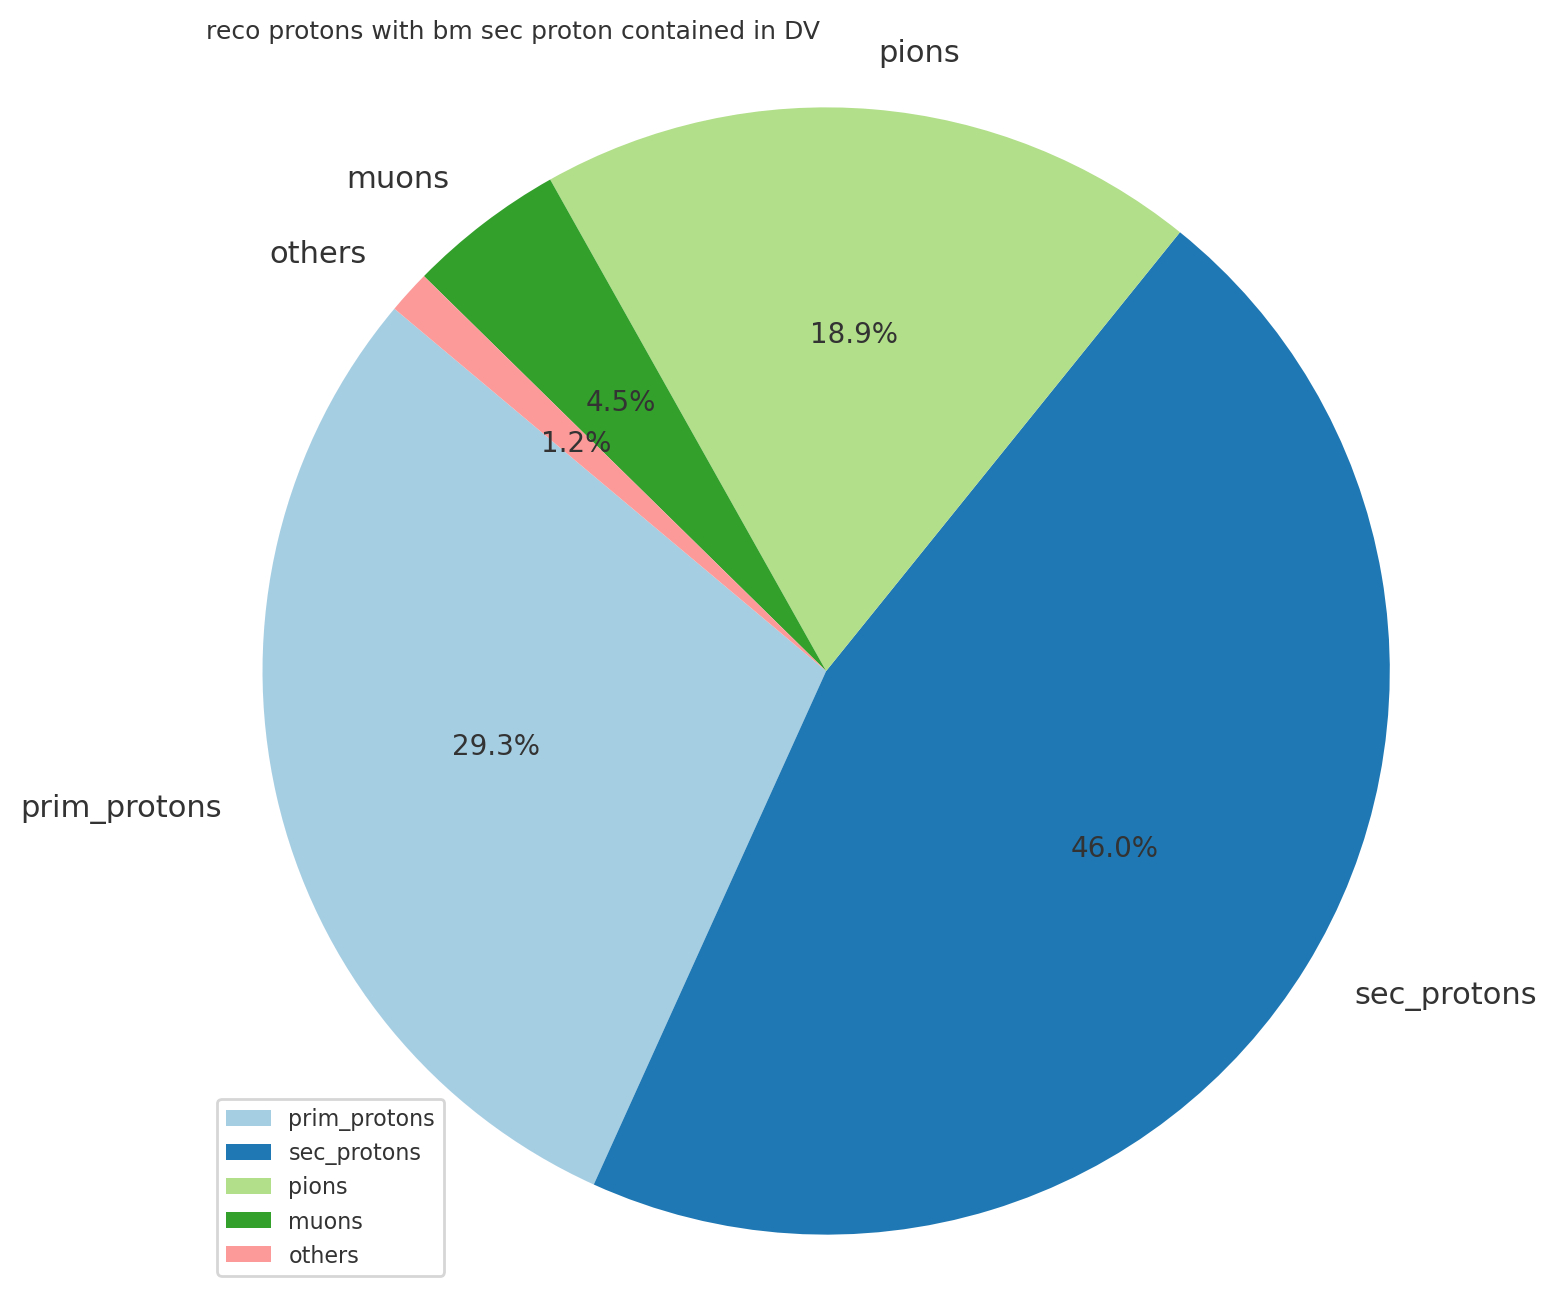

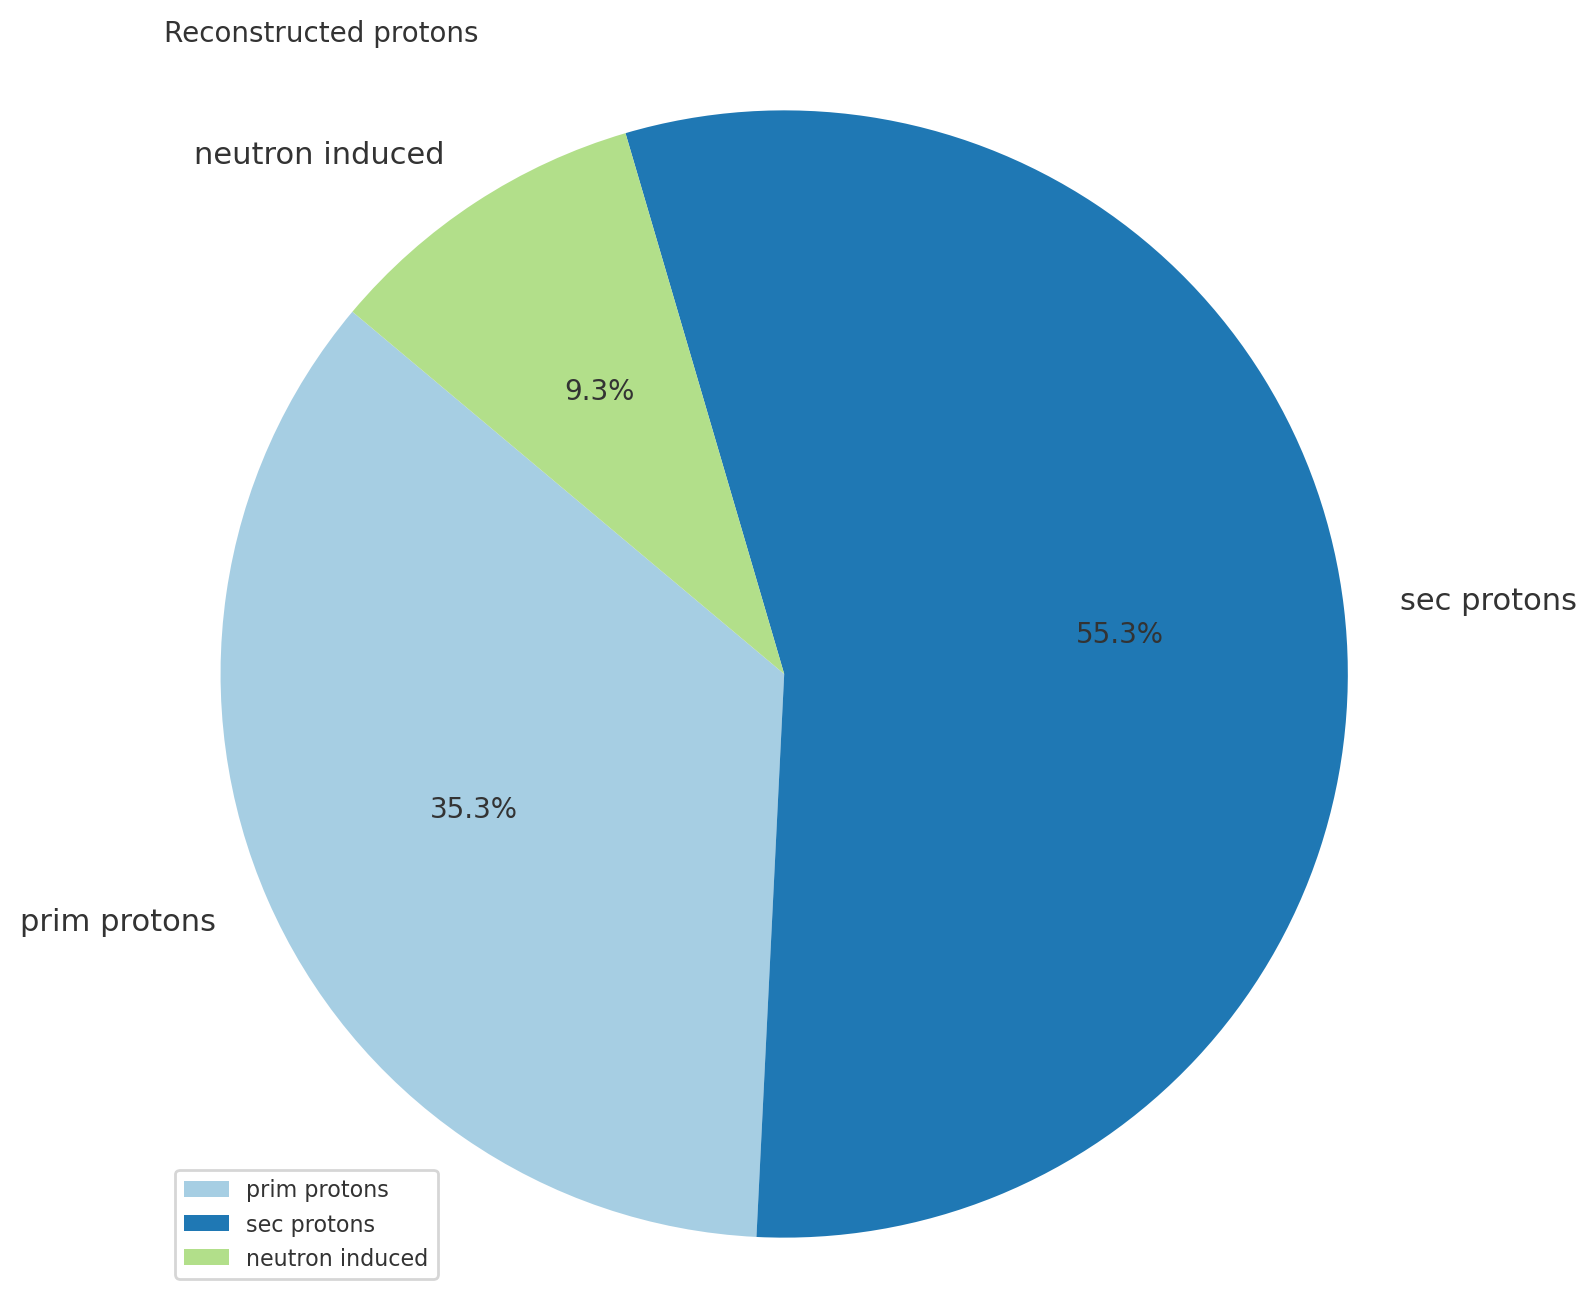

In [249]:
#case 1: reco sec proton with bm sec fully contained 
import numpy as np
from collections import Counter

pdgs = np.array(reco_proton_dic['best_match_pdg'])
tipo = np.array(reco_proton_dic['best_match_type'])
bmlength = np.array(reco_proton_dic['best_match_length'])
bmdistance = np.array(reco_proton_dic['best_match_distance'])
recolength = np.array(reco_proton_dic['reco_length'])
recodistance = np.array(reco_proton_dic['reco_distance'])

# Define masks
bm_prim_protons_mask = (pdgs == pdg_tab.proton) & (tipo == 1)
bm_sec_protons_mask = (pdgs == pdg_tab.proton) & (tipo == 3)

# Count occurrences
C = Counter(np.abs(pdgs))
np.unique(pdgs), len(pdgs)
print(C)
total_protons = C[2212]
total=len(pdgs)
print(f'total protons:{total_protons}, total particles: {total}')
# Add counts for specific particles
C['2212_prim'] = np.sum(bm_prim_protons_mask)
C['2212_sec'] = np.sum(bm_sec_protons_mask)

# Initialize dictionary
dic_results = {
   'prim_protons': 0,
   'sec_protons': 0,
   'pions': 0,
   'muons': 0,
   'others': 0
}

# Populate dictionary with counts
for key, value in C.items():
   if key == '2212_prim':
      dic_results['prim_protons'] = value
   elif key == '2212_sec':
      dic_results['sec_protons'] = value
   elif key == 211:
      dic_results['pions'] = value
   elif key == 13:
      dic_results['muons'] = value
   elif key== 2212: continue
 #     dic_results['all_protons'] = value
   else: 
      dic_results['others'] += value  # Use += to add to the count

print(dic_results)

labels = dic_results.keys()
sizes = dic_results.values()
colors = plt.cm.Paired(range(len(labels)))  # Color map for distinct colors

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)#, fontsize=8)
plt.title('reco protons with bm sec proton contained in DV', fontsize=9,loc='left')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(fontsize =8,loc='lower left')
plt.show()

protons_info = [np.sum(bm_prim_protons_mask), np.sum(bm_sec_protons_mask), len(sample_dic['reco_energy']) ]
percents = np.array([np.sum(bm_prim_protons_mask), np.sum(bm_sec_protons_mask), len(sample_dic['reco_energy']) ])*100/(total_protons)
percents

labels = ['prim protons', 'sec protons','neutron induced']
sizes = np.array([np.sum(bm_prim_protons_mask), np.sum(bm_sec_protons_mask), len(sample_dic['reco_energy']) ])*100/(total_protons)
colors = plt.cm.Paired(range(len(labels)))  # Color map for distinct colors

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)#, fontsize=8)
plt.title('Reconstructed protons', fontsize=10,loc='left')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend(fontsize =8,loc='lower left')
plt.show()


['prim_protons (28.99%)', 'sec_protons (45.40%)', 'pions (18.71%)', 'muons (4.45%)', 'others (1.23%)']
{'prim_protons': 28.987730061349694, 'sec_protons': 45.39877300613497, 'pions': 18.711656441717793, 'muons': 4.447852760736196, 'others': 1.2269938650306749}


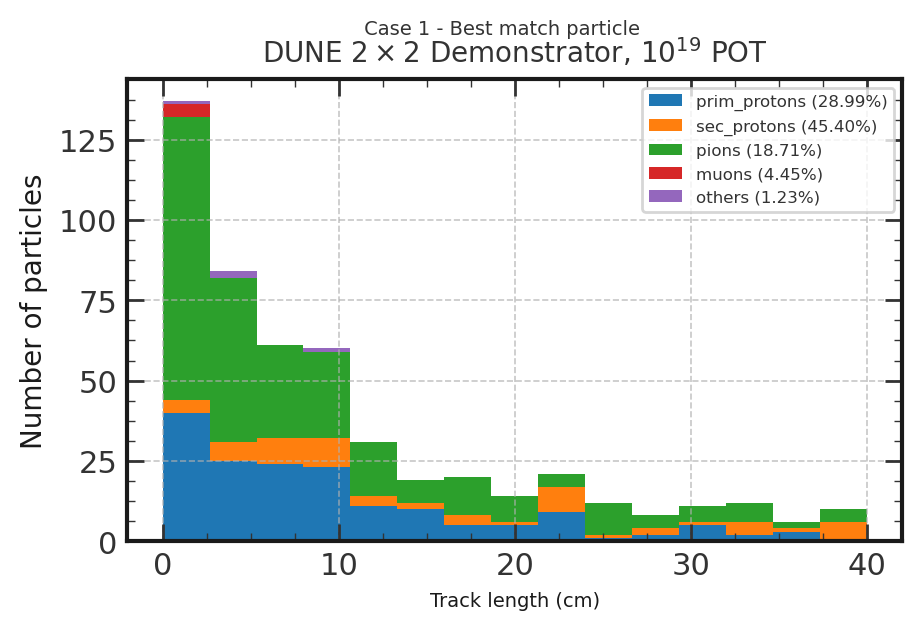

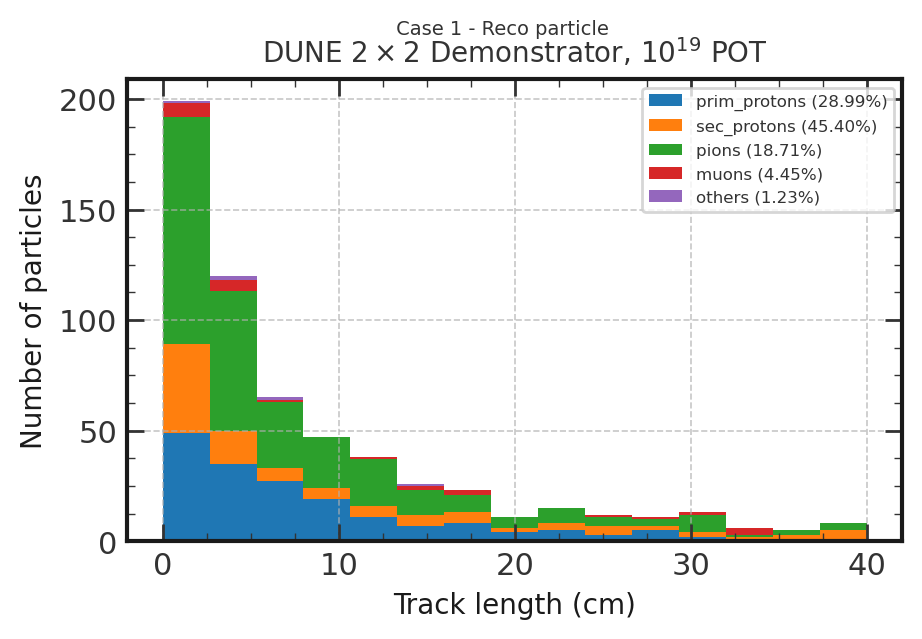

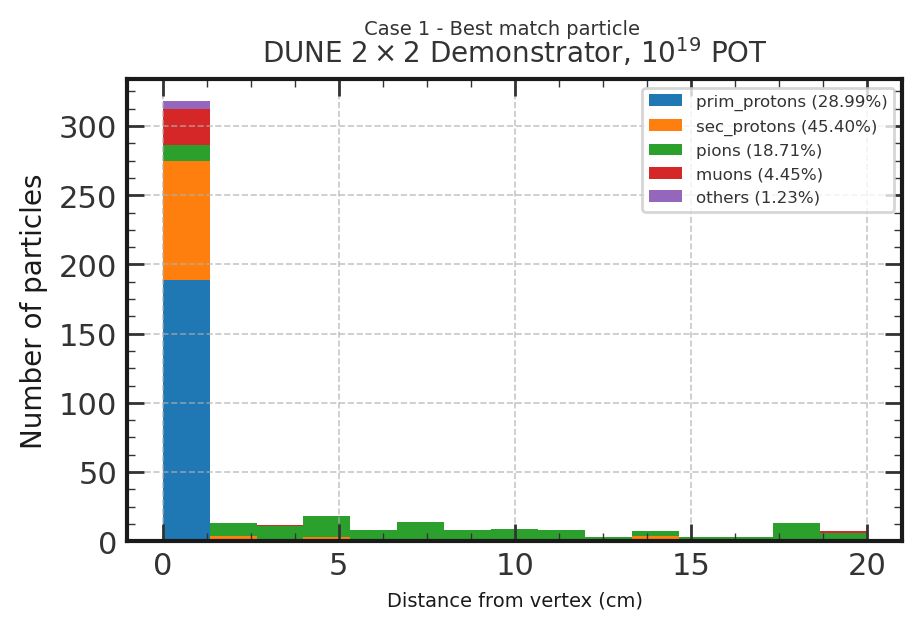

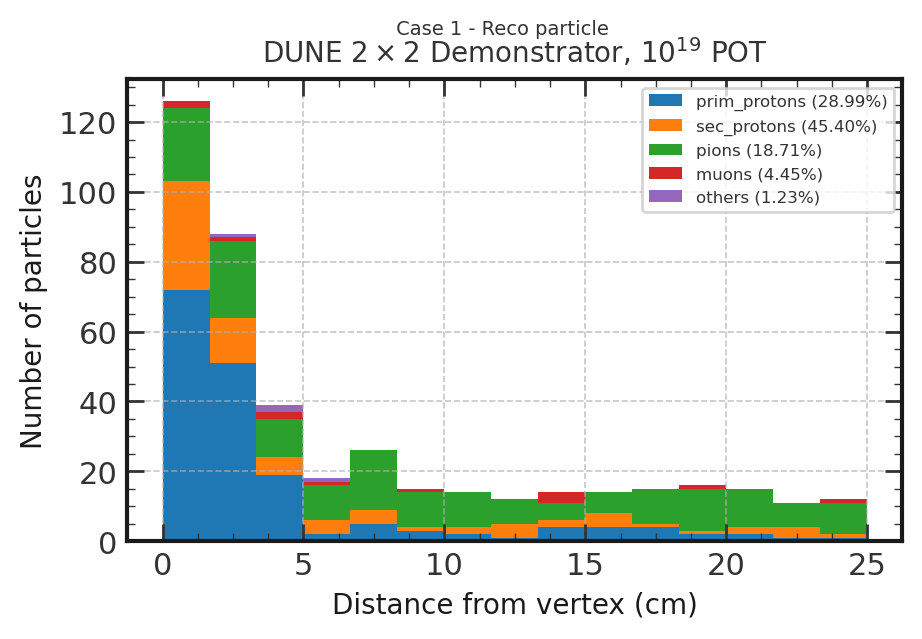

In [253]:
bmlentrack = {}
bmdistancetrack ={}

recolentrack = {}
recodistancetrack ={}

percents={}
#dic_results

for i,value in dic_results.items():
    if i =='prim_protons':
        bmlentrack[i] = bmlength[bm_prim_protons_mask]
        bmdistancetrack[i] = bmdistance[bm_prim_protons_mask]
        recolentrack[i] = recolength[bm_prim_protons_mask]
        recodistancetrack[i] = recodistance[bm_prim_protons_mask]
        percents[i] = (value/total)*100
    elif i == 'pions':
        # Use bitwise OR for element-wise logical operations
        bmlentrack[i] = bmlength[(np.abs(pdgs) == 211)]
        bmdistancetrack[i] = bmdistance[((np.abs(pdgs) == 211))]
        recolentrack[i] = recolength[(np.abs(pdgs) == 211)]
        recodistancetrack[i] = recodistance[((np.abs(pdgs) == 211))]
        percents[i] = (value/total)*100
    elif i =='sec_protons':
        bmlentrack[i] = bmlength[bm_sec_protons_mask]
        bmdistancetrack[i] = bmdistance[bm_sec_protons_mask]
        recolentrack[i] = recolength[bm_sec_protons_mask]
        recodistancetrack[i] = recodistance[bm_sec_protons_mask]
        percents[i] = (value/total)*100
    elif i == 'muons':
        bmlentrack[i] = bmlength[(np.abs(pdgs) == 13)]
        bmdistancetrack[i] = bmdistance[((np.abs(pdgs) == 13))]
        recolentrack[i] = recolength[(np.abs(pdgs) == 13)]
        recodistancetrack[i] = recodistance[((np.abs(pdgs) == 13))]
        percents[i] = (value/total)*100
    else:
        bmlentrack['others'] = bmlength[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        bmdistancetrack['others'] = bmdistance[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        recolentrack['others'] = recolength[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        recodistancetrack['others'] = recodistance[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        percents['others'] = (value/total)*100


labels=[]
for key, value in percents.items():
    if key=='others':continue
    labels.append(f'{key} ({value:.2f}%)')
labels.append(f'others ({percents['others']:.2f}%)')

print(labels)
print(percents)

plt.hist([bmlentrack['prim_protons'], bmlentrack['pions'], bmlentrack['sec_protons'], bmlentrack['muons'], bmlentrack['others']], bins=15, stacked=True, range=[0,40],label=labels)
plt.xlabel('Track length (cm)', fontsize='7')
plt.ylabel('Number of particles', fontsize=10)
plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
plt.suptitle(r' Case 1 - Best match particle ', fontsize = '7')
plt.legend(loc='upper right', fontsize='6') 
plt.show()

plt.hist([recolentrack['prim_protons'], recolentrack['pions'], recolentrack['sec_protons'], recolentrack['muons'], recolentrack['others']], bins=15, stacked=True, range=[0,40],label=labels)
plt.xlabel('Track length (cm)', fontsize='10')
plt.ylabel('Number of particles', fontsize=10)
plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
plt.suptitle(r' Case 1 - Reco particle ', fontsize = '7')
plt.legend(loc='upper right', fontsize='6') 
plt.show()

plt.hist([bmdistancetrack['prim_protons'], bmdistancetrack['pions'], bmdistancetrack['sec_protons'], bmdistancetrack['muons'], bmdistancetrack['others']], bins=15, stacked=True, range=[0,20],label=labels)
plt.xlabel('Distance from vertex (cm)', fontsize='7')
plt.ylabel('Number of particles', fontsize=10)
plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
plt.suptitle(r' Case 1 - Best match particle ', fontsize = '7')
plt.legend(loc='upper right', fontsize='6') 
#plt.yscale('log')
plt.show()

plt.hist([recodistancetrack['prim_protons'], recodistancetrack['pions'], recodistancetrack['sec_protons'], recodistancetrack['muons'], recodistancetrack['others']], bins=15, stacked=True, range=[0,25],label=labels)
plt.xlabel('Distance from vertex (cm)', fontsize='10')
plt.ylabel('Number of particles', fontsize=10)
plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
plt.suptitle(r' Case 1 - Reco particle ', fontsize = '7')
plt.legend(loc='upper right', fontsize='6') 
plt.show()





In [ ]:

# plt.hist([bmdistance['prim_protons'], bm['pions'], bm['sec_protons'], bm['muons'], bm['others']], bins=15, stacked=True, range=[0,40],label=labels)
# plt.xlabel('Reconstructed as sec proton track length (cm)', fontsize='7')
# plt.ylabel('Number of particles', fontsize=10)
# plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
# plt.suptitle(r' Case 1 - Best match particle ', fontsize = '7')
# plt.legend(loc='upper right', fontsize='6') 
# plt.show()

# plt.hist([reco['prim_protons'], reco['pions'], reco['sec_protons'], reco['muons'], reco['others']], bins=15, stacked=True, range=[0,40],label=labels)
# plt.xlabel('Reconstructed as sec proton track length (cm)', fontsize='10')
# plt.ylabel('Number of particles', fontsize=10)
# plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
# plt.suptitle(r' Case 1 - Reco particle ', fontsize = '7')
# plt.legend(loc='upper right', fontsize='6') 
# plt.show()


# plt.hist([distance['masked_13'], distance['masked_211'],  distance['masked_321'], distance['masked_2212'], distance['masked_3222']], bins=30, stacked=True, label=['muons', 'pions', 'kaons', 'protons', 'sigmas'])
# plt.xlabel('distance length ')
# plt.ylabel('Frequency')
# plt.legend()
# plt.show()

In [240]:
# # sample_dic['reco_length'].append(track_length)
# # sample_dic['reco_distance'].append(track_length)
# # sample_dic['reco_energy'].append(reco_energy)
# # sample_dic['best_match_energy'].append(best_match_energy)
# # sample_dic['best_match_distance'].append(vtx_distance_truth)
# # sample_dic['best_match_length'].append(track_length_truth)



In [227]:
#this gather TRUE INFO neutron induced proton info, neutrons percents in the signal, etc
num_neutrinos_total = 0
num_prim_neutrons_total =0 #num of primary neutrons in the simulation
num_neutrons_fv=0  #num of neutrons in the fiducial volume
num_neutrons_dv = 0 #num of neutrons in the detector
num_neutrons_signal =0 #num of neutrons on the signal: cc numu Ar fd
num_out_muon =0 

#store energies 
E_neutrino_all = []
E_neutrino_Ar = [] #store neutrino energy within FV with Ar
E_neutrino_dv_Ar = [] #store neutrino energy within detector with Ar
E_neutrino_fv_Ar = [] #store neutrino energy within FV with Ar
E_neutrino_signal = [] #store neutrino energy of signal ccnumu FV Ar
E_neutrino_w_prim_neutrons = [] #store neutrino energies of int that produced primary neutrons
E_prim_neutrons_signal = [] #store energies of the primary neutrons in the signal
E_neutron_parents = [] #store energy of the neutrons that are proton parents
E_neutrino_n_p = [] #store neutrino energy of the interactions that produced n->p
E_proton =[] #store energy of neutron induced protonse

#store proton tracks info
track_vtx_distances = [] #distance of the proton track to the vertex
track_lengths= [] #proton track lenght 
track_lengths2= []
track_vtx_distances2=[]
# Create lists to store the vertex positions of vtx that happen in FV
vertices_x = []
vertices_y = []
vertices_z = []

#store vertices of the signal that exit 2x2 downstream
vx_t=[]
vy_t=[]
vz_t=[]


for event in range(len(df)):

    ev_data= df.iloc[event]

    #Mask vertex on the detector volume
    mask_dv = (
                (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                )
    
    #mask Ar in DV
    mask_dv_Ar = (
        mask_dv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )

    #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )
    #mask Ar in FV
    mask_fv_Ar = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    #mask vertex on fv, Ar, CC numu
    mask_signal = (
        mask_fv&
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )

    vertices_x.extend(ev_data['rec.mc.nu.vtx.x'][mask_signal])
    vertices_y.extend(ev_data['rec.mc.nu.vtx.y'][mask_signal])
    vertices_z.extend(ev_data['rec.mc.nu.vtx.z'][mask_signal])

    #some data we can gather directly:
    n_vtx = len(ev_data['rec.mc.nu.E']) 
    E_neutrino_all.extend(ev_data['rec.mc.nu.E'])
    num_neutrinos_total +=  ev_data['rec.mc.nu..length']
    E_neutrino_Ar.extend(ev_data['rec.mc.nu.E'][(ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)])
    E_neutrino_dv_Ar.extend(ev_data['rec.mc.nu.E'][mask_dv_Ar]) 
    E_neutrino_fv_Ar.extend(ev_data['rec.mc.nu.E'][mask_fv_Ar])  
    E_neutrino_signal.extend(ev_data['rec.mc.nu.E'][mask_signal]) #ccmunu df
    num_prim_neutrons_total += sum(ev_data['rec.mc.nu.nneutron']) #this is only primaries
    num_neutrons_dv += sum(ev_data['rec.mc.nu.nneutron'][mask_dv])
    num_neutrons_fv += sum(ev_data['rec.mc.nu.nneutron'][mask_fv])
    num_neutrons_signal += sum(ev_data['rec.mc.nu.nneutron'][mask_signal])

    signal_out_muon = find_end_muon(ev_data, mask_signal)
    num_out_muon += np.sum(signal_out_muon)

    vx_t.extend(ev_data['rec.mc.nu.vtx.x'][signal_out_muon])
    vy_t.extend(ev_data['rec.mc.nu.vtx.y'][signal_out_muon])
    vz_t.extend(ev_data['rec.mc.nu.vtx.z'][signal_out_muon])

    #now let's gather the data from neutrons that produced protons

    for vtx in range(n_vtx):  # Using num interactions directly as the range
    
        #if vtx it is not in the signal, skip vtx
        if (mask_signal[vtx]==False):
            continue
        else:
            #now check for neutrons with proton daughter 
            #a vtx can produce several neutrons, we need to ensure we include the vtx info only one time 
            #E.g. an vtx might have more than one neutron, but it's still same vtx.
            tracked_neutron_ids = set() #track the vtx that we already count
            n_prim = ev_data['rec.mc.nu.prim..length'][vtx] #num of total prim
            n_sec = ev_data['rec.mc.nu.sec..length'][vtx]   #num of total sec


            #Luis's trick to iterate between primaries/sec per vtx
            if vtx == 0:
                n_pred_prim = 0
                n_pred_sec = 0
            else:
                n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx])
                n_pred_sec = np.sum(ev_data['rec.mc.nu.sec..length'][:vtx])

            #false if you haven't included that vtx, if a neutrons is found then True
            included_vertex=False  
            included_vertex_np = False  #to count neutrons that produced protons

            #iterates over all primaries of the interaction. 
            # This finds info from primary neutrons
            for ip in range(n_pred_prim, n_pred_prim + n_prim):
                if (ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron):
                    #Store energy of primary neutrons. Sanity-check: length must match num_prim_neutrons_signal
                    E_prim_neutrons_signal.append(ev_data['rec.mc.nu.prim.p.E'][ip])              
                    #save the neutrino energy of the vtx that produced at least one prim neutron
                    if included_vertex == False: 
                        E_neutrino_w_prim_neutrons.extend(ev_data['rec.mc.nu.E'][mask_signal])
                        included_vertex= True  #make true so we don't overcount the interactions/vertex
                    else: pass  #skip vtx if you already included it 

            # iterate over secondary particles to find neutron-induced protons
            for isec in range(n_pred_sec, n_pred_sec + n_sec):
                # check if any of the secondary particles are protons
                if ev_data['rec.mc.nu.sec.pdg'][isec] == pdg_tab.proton:
                    # if proton, save the G4 ID of the parent
                    proton_parent_id = ev_data['rec.mc.nu.sec.parent'][isec]
                    # iterate over primary particles to find parent 
                    for ip in range(n_pred_prim, n_pred_prim + n_prim):
                        if (
                            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
                            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
                        ):
                            # This interaction has a proton produced by a neutron
                            if included_vertex_np == False:
                                E_neutrino_n_p.extend(ev_data['rec.mc.nu.E'][mask_signal]) #save energy of the interaction
                                included_vertex_np= True #make true so we don't overcount the interactions/vertex
                            else: pass #skip vtx if you already included it 

                            if proton_parent_id not in tracked_neutron_ids:
                                #vtx_n_p[vtx] = True
                                #get energies and calculate distance to vertex
                                E_neutron_parents.append(ev_data['rec.mc.nu.prim.p.E'][ip])
                                E_proton.append(ev_data['rec.mc.nu.sec.p.E'][isec])
                                tracked_neutron_ids.add(proton_parent_id)
                                #proton distance to vertex
                                iscontained_p = isContainedFV(ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec], 2)
                                
                                if iscontained_p:
                                    track_length, vtx_distance = calculate_track_properties(
                                        (ev_data['rec.mc.nu.sec.start_pos.x'][isec], ev_data['rec.mc.nu.sec.start_pos.y'][isec], ev_data['rec.mc.nu.sec.start_pos.z'][isec]),
                                        (ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec]),
                                        (ev_data['rec.mc.nu.vtx.x'][vtx], ev_data['rec.mc.nu.vtx.y'][vtx], ev_data['rec.mc.nu.vtx.z'][vtx])
                                    )
                                    track_lengths.append(track_length)
                                    track_vtx_distances.append(vtx_distance)

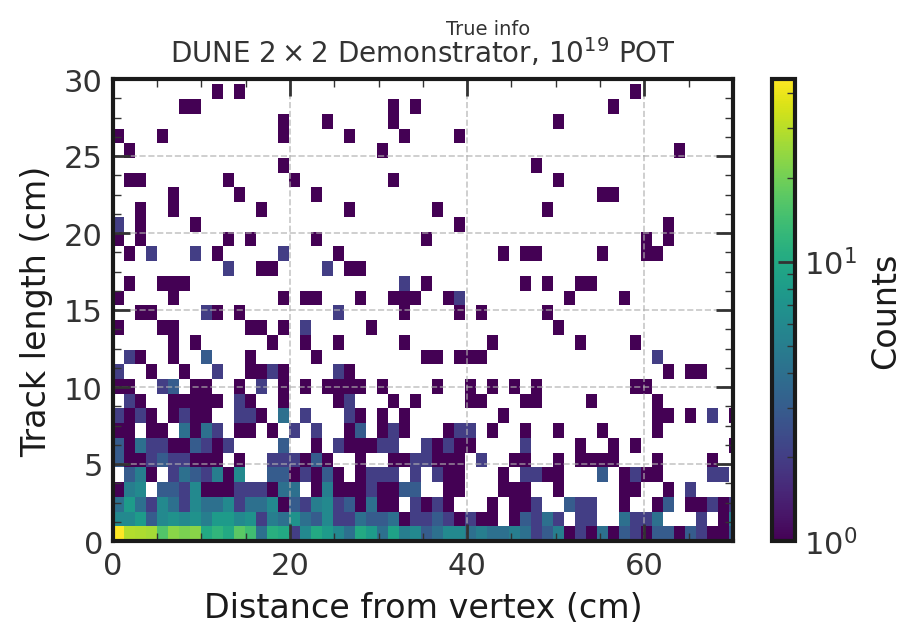

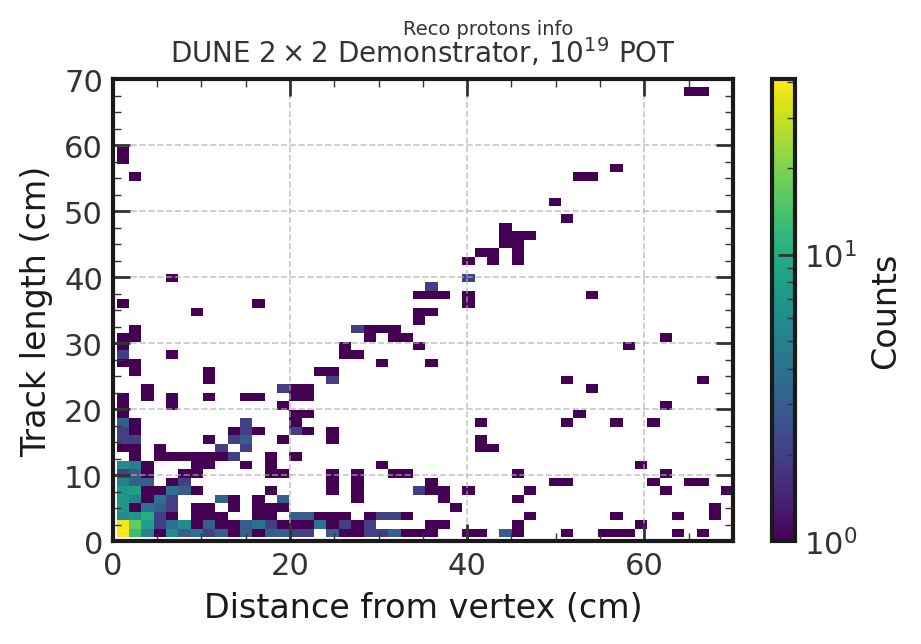

In [260]:


plt.hist2d(track_vtx_distances,track_lengths,  bins=100, norm=mcolors.LogNorm(), cmap='viridis')
# plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 70)
plt.ylim(0, 30)
plt.colorbar(label='Counts')
plt.ylabel('Track length (cm)')
plt.xlabel('Distance from vertex (cm)')
#plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.suptitle(r'True info', fontsize = '7')
#plt.legend(fontsize='8')
plt.show()

plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 70)
plt.ylim(0, 70)
plt.colorbar(label='Counts')
plt.ylabel('Track length (cm)')
plt.xlabel('Distance from vertex (cm)')
#plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.suptitle(r'Reco protons info', fontsize = '7')
#plt.legend(fontsize='8')
plt.show()


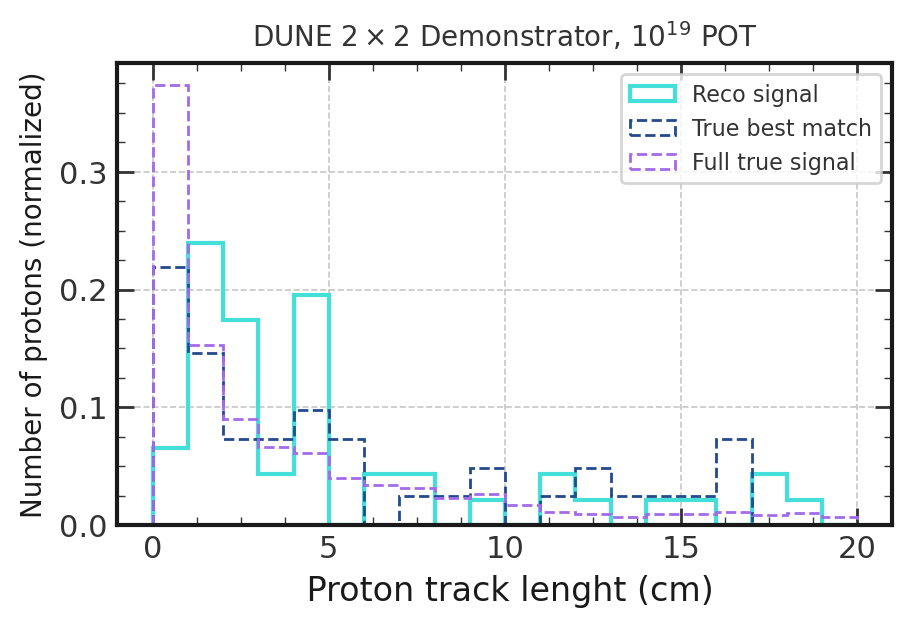

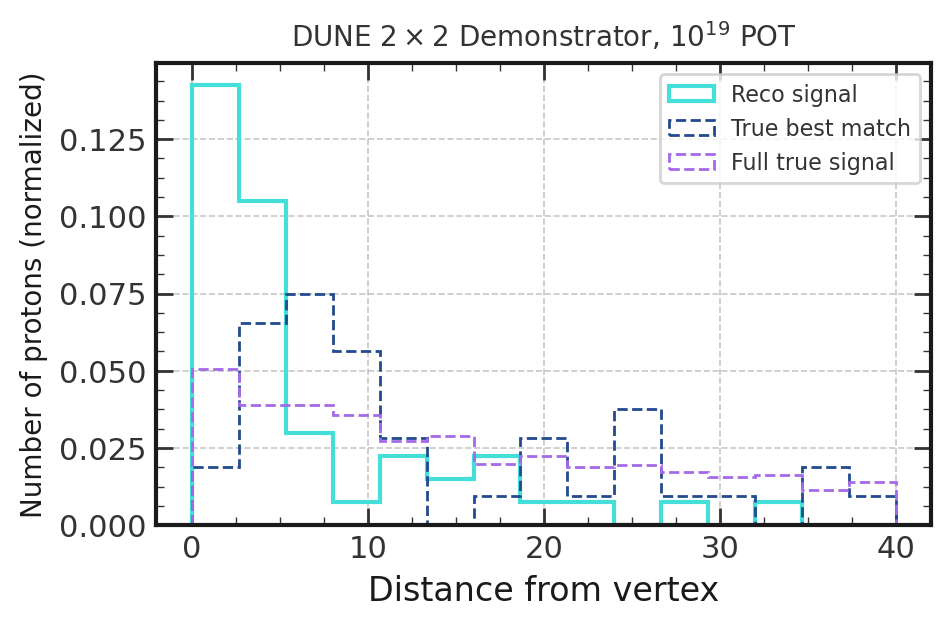

In [281]:
plt.hist(sample_dic['reco_length'],bins=20,histtype='step', range=[0,20], color='#43dfd8', linewidth=1.5,density=True,label=r'Reco signal')
plt.hist(sample_dic['best_match_length'],bins=20,histtype='step',range=[0,20], color='#224a8e',linestyle='--', density=True,linewidth=1,label=r'True best match')
plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
plt.xlabel(' Proton track lenght (cm)')
plt.ylabel('Number of protons (normalized)', fontsize='10')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.legend(loc='upper right', fontsize='8') 
plt.show()

plt.hist(sample_dic['reco_distance'],bins=15,histtype='step', range=[0,40], color='#43dfd8', linewidth=1.5,density=True,label=r'Reco signal')
plt.hist(sample_dic['best_match_distance'],bins=15,histtype='step',range=[0,40], color='#224a8e',linestyle='--', density=True,linewidth=1,label=r'True best match')
plt.hist(track_vtx_distances,bins=15,histtype='step',range=[0,40], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
plt.xlabel('Distance from vertex')
plt.ylabel('Number of protons (normalized)', fontsize='10')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.legend(loc='upper right', fontsize='8') 
plt.show()

# plt.hist(sample_dic['reco_energy'],bins=20,histtype='step', range=[0,2], color='#43dfd8', linewidth=1.5,density=True,label=r'Reco signal')
# plt.hist(sample_dic['best_match_energy'],bins=20,histtype='step',range=[0,2], color='#224a8e',linestyle='--', density=True,linewidth=1,label=r'True best match')
# #plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
# plt.xlabel(' Proton track lenght (cm)')
# plt.ylabel('Number of protons (normalized)', fontsize='10')
# plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
# plt.legend(loc='upper right', fontsize='8') 
# plt.show()

In [ ]:
# Load datasets 
n_files = 998
location = "nersc"
df = load_dataset(n_files,location)
# Create a caf reader
caf_reader = CafReader(df)
pdg_tab = ParticleCode()

In [302]:
#store num reco vtx for the cuts
num_neutrinos_dv_r=0 # in dv
num_neutrinos_fv_r=0 # in fv
num_neutrinos_muons = 0 #produced reco muon
num_neutrinos_muon_fv = 0 #produced reco muon in fv
num_neutrinos_prim_mu_fv=0 #produced prim muon in fv
#for tracks
num_track_fv = 0 # produced a track in fv
num_track_vtx_fv =0 #produced track that stat on vtx
num_track_vtx_out_fv=0 #produced track start on vtx and exit 2x2 downstream
num_track_Mx2_fv = 0 #num of tracks that crossed minerva 


reco_sec_proton=0
reco_primproton_with_bm_sec_proton  =0
reco_prim_proton =0
candidate_not_in_signal=0
candidate_in_signal =0 
count_sec =0

#store track length and distance to vtx 
track_lenghts_match_truth = [] #true particles best match 
vtx_distances_match_truth =[]  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#positions of the vtx that passed the reco signal cuts
vtx_x_signal=[]
vtx_y_signal=[]
vtx_z_signal=[]
#positions of the vtx the reco candidates
vtx_x_candidates=[]
vtx_y_candidates=[]
vtx_z_candidates=[]

candidate_event_vtx_r = []
candidate_event_vtx_t = []

vtx_x_bmcandidates=[]
vtx_y_bmcandidates=[]
vtx_z_bmcandidates=[]


bmnot_a_proton =[]
bmtrue_prim_proton=[]
bmtrue_intermediate_proton=[]

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],

}

len_all=[]
dist_all =[]

len_alltrue=[]
dist_alltrue =[]

c=0
sec_protons=0
for ev in range(len(df)):
    


    ev_data= df.iloc[ev]

     #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )

    #mask vertex on the fiducial volume
    mask_fv_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])<zbound-tpc_dist)
    )
    
    for vtx, value in enumerate(mask_fv):
        if value == True:
            n_prim = ev_data['rec.mc.nu.prim..length'][vtx] #num of total prim
            n_sec = ev_data['rec.mc.nu.sec..length'][vtx]   #num of total sec

            #Luis's trick to iterate between primaries/sec per vtx
            if vtx == 0:
                n_pred_prim = 0
                n_pred_sec = 0
            else:
                n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx])
                n_pred_sec = np.sum(ev_data['rec.mc.nu.sec..length'][:vtx])

            for ip in range(n_pred_prim, n_pred_prim + n_prim):
                if (ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.proton):
                    iscontained_p = isContainedFV(ev_data['rec.mc.nu.prim.end_pos.x'][ip], ev_data['rec.mc.nu.prim.end_pos.y'][ip], ev_data['rec.mc.nu.prim.end_pos.z'][ip], 2)
                    if iscontained_p:
                        track_length, vtx_distance = calculate_track_properties(
                            (ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]),
                            (ev_data['rec.mc.nu.prim.end_pos.x'][ip], ev_data['rec.mc.nu.prim.end_pos.y'][ip], ev_data['rec.mc.nu.prim.end_pos.z'][ip]),
                            (ev_data['rec.mc.nu.vtx.x'][vtx], ev_data['rec.mc.nu.vtx.y'][vtx], ev_data['rec.mc.nu.vtx.z'][vtx])
                        )
                        len_alltrue.append(track_length)
                        dist_alltrue.append(vtx_distance)

            for isec in range(n_pred_sec, n_pred_sec + n_sec):
                if (ev_data['rec.mc.nu.sec.pdg'][isec] == pdg_tab.proton):
                    iscontained_p = isContainedFV(ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec], 2)
                    if iscontained_p:
                        track_length, vtx_distance = calculate_track_properties(
                            (ev_data['rec.mc.nu.sec.start_pos.x'][isec], ev_data['rec.mc.nu.sec.start_pos.y'][isec], ev_data['rec.mc.nu.sec.start_pos.z'][isec]),
                            (ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec]),
                            (ev_data['rec.mc.nu.vtx.x'][vtx], ev_data['rec.mc.nu.vtx.y'][vtx], ev_data['rec.mc.nu.vtx.z'][vtx])
                        )
                        len_alltrue.append(track_length)
                        dist_alltrue.append(vtx_distance)

    
                

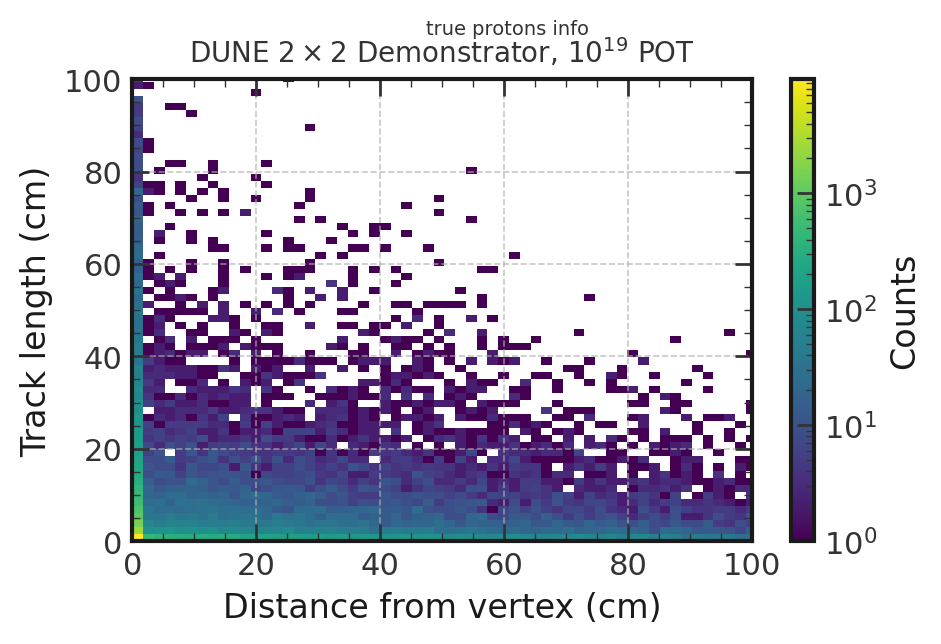

In [305]:
plt.hist2d(dist_alltrue, len_alltrue, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.colorbar(label='Counts')
plt.ylabel('Track length (cm)')
plt.xlabel('Distance from vertex (cm)')
#plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.suptitle(r'true protons info', fontsize = '7')
#plt.legend(fontsize='8')
plt.show()

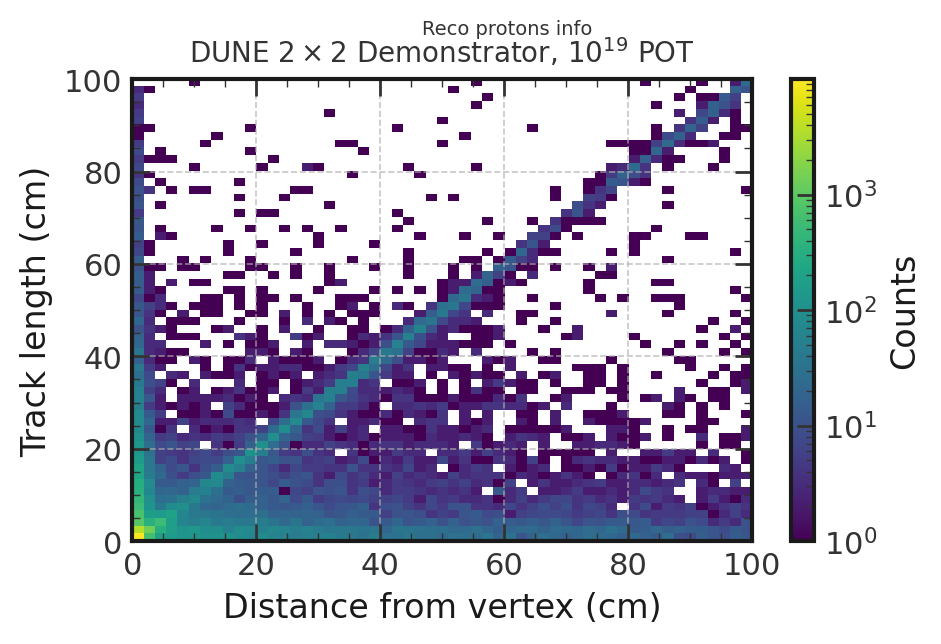

In [298]:
plt.hist2d(dist_all, len_all, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.colorbar(label='Counts')
plt.ylabel('Track length (cm)')
plt.xlabel('Distance from vertex (cm)')
#plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.suptitle(r'Reco protons info', fontsize = '7')
#plt.legend(fontsize='8')
plt.show()
